<h1>Table of contents</h1>

<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Quadratic">Quadratic</a></li>
        <li><a href="#Exponential">Exponential</a></li>
        <li><a href="#Logarithmic">Logarithmic</a></li>
        <li><a href="#Sigmoidal/Logistic">Sigmoidal/Logistic</a></li>
        <li><a href="#Data">Data</a></li>
        <li><a href="#Selecting-And-Preprocessing">Selecting And Preprocessing</a></li>
        <li><a href="#Model">Model</a></li>
        <li><a href="#Evaluation">Evaluation</a></li>
    </ol>
</div>
<br>
<hr>

# importing libs

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Quadratic
$$ Y = X^2 $$

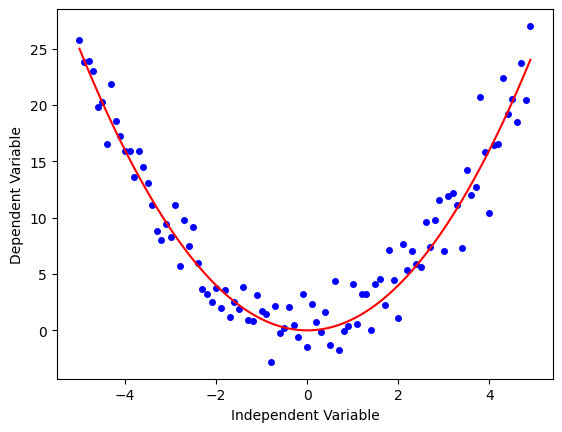

In [2]:
x = np.arange(-5.0, 5.0, 0.1)
y = np.power(x,2)

y_noise = 2 * np.random.normal(size=x.size)
ydata = y + y_noise

plt.plot(x, ydata,  'bo' , markersize=4)
plt.plot(x,y, 'r') 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

### Exponential
$$ Y = a + b c^X $$

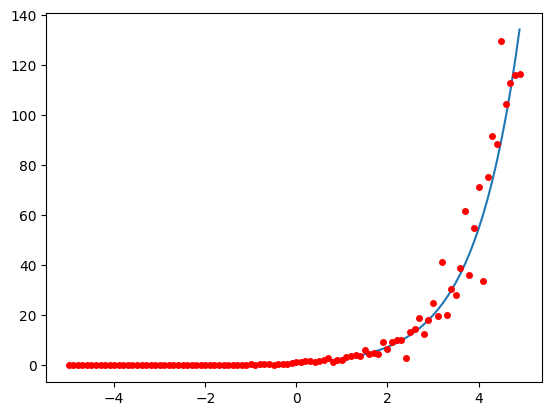

In [3]:
X_exp = np.arange(-5.0, 5.0, 0.1)
Y_exp = np.exp(X_exp)

noise = 0.3* np.random.normal(size=X_exp.size)
ydata = Y_exp * (1 + noise)

plt.plot(X_exp, Y_exp, label='exp(x)')
plt.plot(X_exp, ydata, 'ro', markersize=4)
plt.show()

### Logarithmic

The response $y$ is a results of applying the logarithmic map from the input $x$ to the output $y$. It is one of the simplest form of **log()**: i.e. $$ y = \log(x)$$

Please consider that instead of $x$, we can use $X$, which can be a polynomial representation of the $x$ values. In general form it would be written as\
\begin{equation}
y = \log(X)
\end{equation}


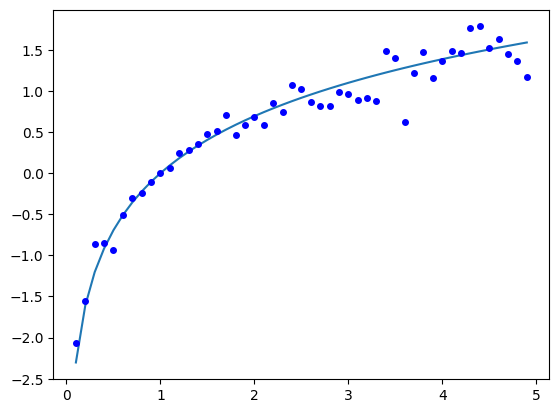

In [4]:
X_log = np.arange(0.1, 5.0, 0.1)
Y_log = np.log(X_log)

ydata_log = Y_log * (1 + 0.2 * np.random.normal(size=X_log.size))

plt.plot(X_log, Y_log, label='log(x)')
plt.plot(X_log, ydata_log, 'bo', markersize=4)
plt.show()

### Sigmoidal/Logistic
<div style= "text-align:center; font-size:20px; margin:25px 0;"> $$ Y = a + \frac{b}{1+ c^{(X-d)}}$$ </div>

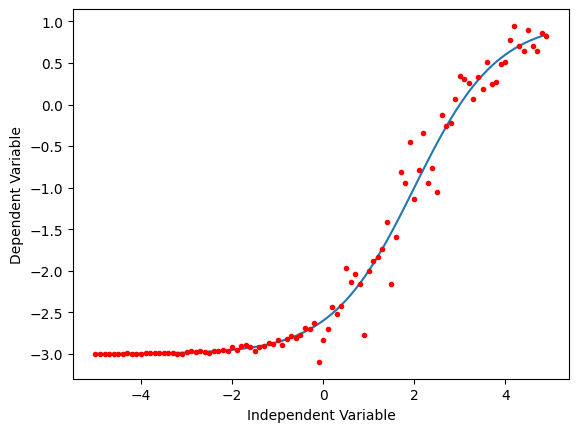

In [5]:
X = np.arange(-5.0, 5.0, 0.1)
Y = 1 - 4/(1 + np.power(3, X-2))

slope = np.gradient(Y)
noise = 4 * np.abs(slope) * np.random.normal(size=X.size)
ydata = Y + noise

plt.plot(X, Y)
plt.plot(X, ydata, 'ro', markersize=3)
plt.xlabel("Independent Variable")
plt.ylabel("Dependent Variable")
plt.show()

<h1 label = "#Data" >Data</h1>

In [7]:
df = pd.read_csv("../data/china_gdp.csv")
df

,Year,Value
0,1960,5.918412e+10
1,1961,4.955705e+10
2,1962,4.668518e+10
3,1963,5.009730e+10
4,1964,5.906225e+10
5,1965,6.970915e+10
6,1966,7.587943e+10
7,1967,7.205703e+10
8,1968,6.999350e+10
9,1969,7.871882e+10


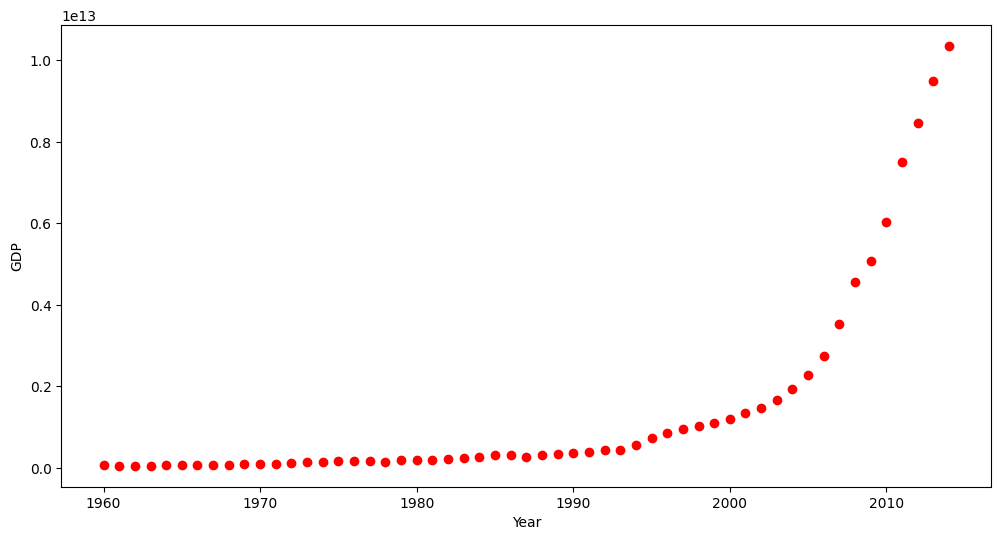

In [17]:
plt.figure(figsize=(12,6))
x_data, y_data = (df["Year"].values, df["Value"].values)
plt.plot(x_data, y_data, 'ro', markersize=6)
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()

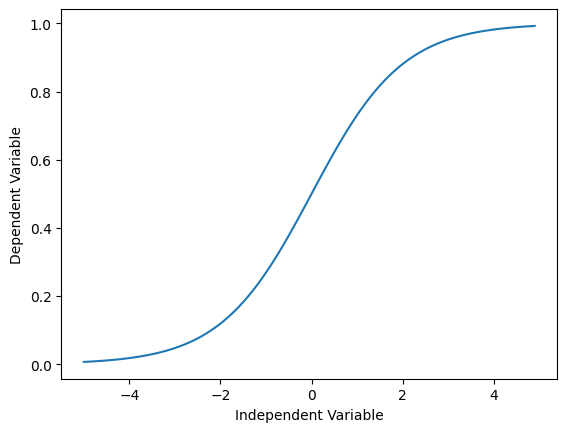

In [30]:
X = np.arange(-5.0, 5.0, 0.1)
Y = 1.0 / (1.0 + np.exp(-X))

plt.plot(X,Y) 
plt.ylabel('Dependent Variable')
plt.xlabel('Independent Variable')
plt.show()

<div style= "text-align:center; font-size:24px; margin:25px 0;">

The formula for the logistic function is the following:

$$ \hat{Y} = \frac1{1+e^{\beta\_1(X-\beta\_2)}}$$

$\beta\_1$: Controls the curve's steepness,

$\beta\_2$: Slides the curve on the x-axis.
</div>

In [25]:
xdata =x_data/max(x_data)
ydata =y_data/max(y_data)

In [22]:
def sigmoid(x, Beta_1, Beta_2):
     y = 1 / (1 + np.exp(-Beta_1*(x-Beta_2)))
     return y

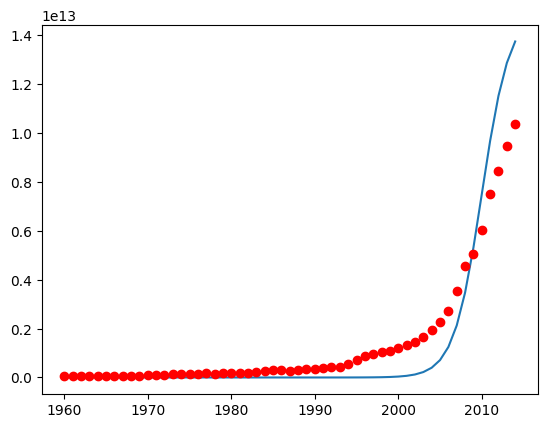

In [34]:
beta_1 = 0.6
beta_2 = 2010.0

Y_pred = sigmoid(x_data, beta_1 , beta_2)

plt.plot(x_data, Y_pred*15000000000000.)
plt.plot(x_data, y_data, 'ro')

In [26]:
from scipy.optimize import curve_fit
popt, pcov = curve_fit(sigmoid, xdata, ydata)
#print the final parameters
print(" beta_1 = %f, beta_2 = %f" % (popt[0], popt[1]))

 beta_1 = 690.451711, beta_2 = 0.997207


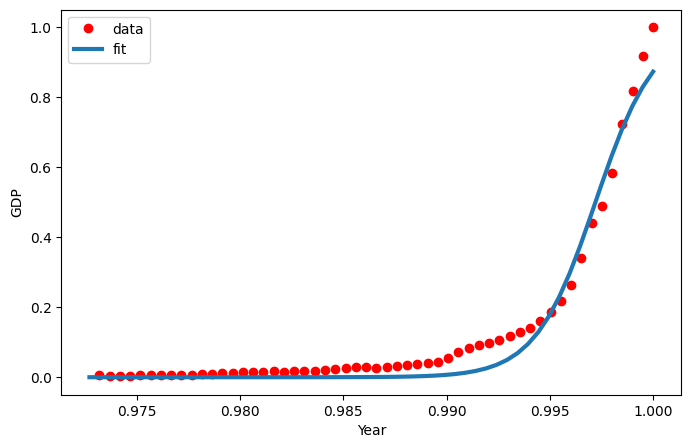

In [27]:
x = np.linspace(1960, 2015, 55)
x = x/max(x)
plt.figure(figsize=(8,5))
y = sigmoid(x, *popt)
plt.plot(xdata, ydata, 'ro', label='data')
plt.plot(x,y, linewidth=3.0, label='fit')
plt.legend(loc='best')
plt.ylabel('GDP')
plt.xlabel('Year')
plt.show()